In [1]:
import pandas as pd

X_train = pd.read_csv("../data/processed/X_train.csv")
X_test = pd.read_csv("../data/processed/X_test.csv")
y_train = pd.read_csv("../data/processed/y_train.csv")
y_test = pd.read_csv("../data/processed/y_test.csv")

print(X_train.shape)
print(X_test.shape)
X_train.columns

(5634, 47)
(1409, 47)


Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges',
       'AvgMonthlyCharges', 'HasInternetService', 'NumServices',
       'ChargesPerService', 'ContractLevel', 'gender_Female', 'gender_Male',
       'Partner_No', 'Partner_Yes', 'Dependents_No', 'Dependents_Yes',
       'PhoneService_No', 'PhoneService_Yes', 'MultipleLines_No',
       'MultipleLines_No phone service', 'MultipleLines_Yes',
       'InternetService_DSL', 'InternetService_Fiber optic',
       'InternetService_No', 'OnlineSecurity_No',
       'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
       'OnlineBackup_No', 'OnlineBackup_No internet service',
       'OnlineBackup_Yes', 'DeviceProtection_No',
       'DeviceProtection_No internet service', 'DeviceProtection_Yes',
       'TechSupport_No', 'TechSupport_No internet service', 'TechSupport_Yes',
       'StreamingTV_No', 'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No', 'StreamingMovies_No internet service',
    

In [2]:
X_cluster = pd.concat(
    [X_train, X_test],
    axis=0
).reset_index(drop=True)
print(X_cluster.shape)
print(X_cluster.dtypes)
print(X_cluster.isna().sum().sum())

(7043, 47)
SeniorCitizen                              float64
tenure                                     float64
MonthlyCharges                             float64
TotalCharges                               float64
AvgMonthlyCharges                          float64
HasInternetService                         float64
NumServices                                float64
ChargesPerService                          float64
ContractLevel                              float64
gender_Female                              float64
gender_Male                                float64
Partner_No                                 float64
Partner_Yes                                float64
Dependents_No                              float64
Dependents_Yes                             float64
PhoneService_No                            float64
PhoneService_Yes                           float64
MultipleLines_No                           float64
MultipleLines_No phone service             float64
MultipleLines_Yes   

In [3]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_cluster)
print("original features: ", X_cluster.shape[1])
print("PCA components: ", X_pca.shape[1])

print("explained variance : ", pca.explained_variance_ratio_.sum())

original features:  47
PCA components:  17
explained variance :  0.9534019826168545


In [4]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score


metrics_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    labels = kmeans.fit_predict(X_pca)
    metrics_scores.append({
        'k': k,
        'inertia': kmeans.inertia_,
        'silhouette': silhouette_score(X_pca, labels),
        'calinski_h': calinski_harabasz_score(X_pca, labels) 
    })
    
print(pd.DataFrame(metrics_scores))

    k       inertia  silhouette   calinski_h
0   2  80256.724684    0.314985  2874.790103
1   3  61375.388863    0.285215  2962.206977
2   4  55911.573916    0.240887  2396.783645
3   5  51158.526710    0.233977  2127.778488
4   6  48164.334358    0.233434  1895.284497
5   7  45682.500329    0.226962  1728.676684
6   8  43319.299655    0.184538  1617.159152
7   9  41707.128969    0.185407  1503.492026
8  10  40529.818151    0.171552  1397.769514


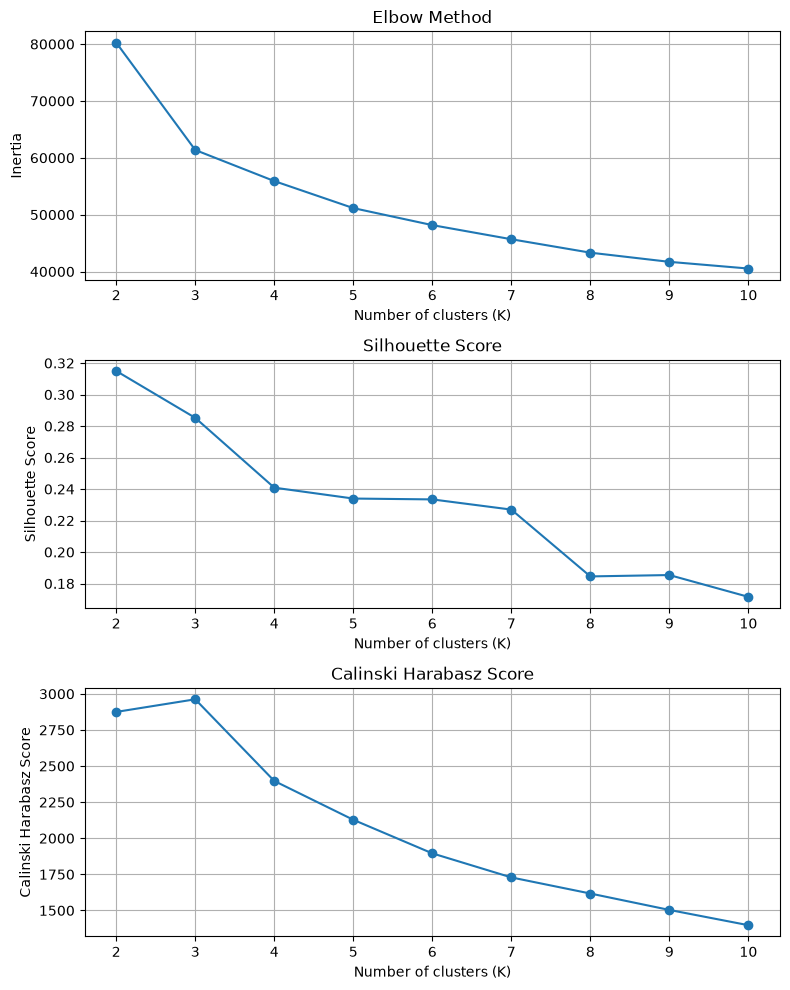

In [5]:
import matplotlib.pyplot as plt

k_values = [item["k"] for item in metrics_scores]

inertia_values = [
    item["inertia"]
    for item in metrics_scores
]

silhouette_values = [
    item["silhouette"]
    for item in metrics_scores
]
calinski_harabasz_values = [
    item["calinski_h"] for item in metrics_scores
]
fig, axes = plt.subplots(
    3, 1,
    figsize=(8, 10)
)

axes[0].plot(
    k_values,
    inertia_values,
    marker="o"
)

axes[0].set_xlabel("Number of clusters (K)")
axes[0].set_ylabel("Inertia")
axes[0].set_title("Elbow Method")
axes[0].grid(True)


axes[1].plot(
    k_values,
    silhouette_values,
    marker="o"
)

axes[1].set_xlabel("Number of clusters (K)")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Score")
axes[1].grid(True)

axes[2].plot(
    k_values,
    calinski_harabasz_values,
    marker="o"
)

axes[2].set_xlabel("Number of clusters (K)")
axes[2].set_ylabel("Calinski Harabasz Score")
axes[2].set_title("Calinski Harabasz Score")
axes[2].grid(True)

plt.tight_layout()
plt.show()

In [6]:
#based on the plots k=3 is the beginning of a smaller decreasing of inertia , also the silhouette score is high

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)
cluster_labels = kmeans.fit_predict(X_pca)
X_cluster["Cluster"] = cluster_labels
print(X_cluster["Cluster"].value_counts().sort_index())

Cluster
0    1526
1    3131
2    2386
Name: count, dtype: int64


In [7]:
clusters = pd.DataFrame({
    "Cluster": cluster_labels
})

clusters.to_csv("../data/processed/cluster_labels.csv", index=False)

In [8]:
y_cluster = pd.concat(
    [y_train, y_test],
    axis=0
    ).reset_index(drop=True).squeeze()
cluster_analysis = pd.DataFrame({
    "Cluster": cluster_labels,
    "Churn": y_cluster
})

print(cluster_analysis.head())
print(cluster_analysis.shape)

   Cluster  Churn
0        1      0
1        1      0
2        1      0
3        2      0
4        1      0
(7043, 2)


In [9]:
print(
   ( cluster_analysis.groupby("Cluster")["Churn"].mean()) * 100
)

Cluster
0     7.404980
1    43.468540
2    16.554904
Name: Churn, dtype: float64


In [10]:
from sklearn.cluster import DBSCAN
dbscan = DBSCAN(
    eps=2.5,
    min_samples=5
)
dbscan_labels = dbscan.fit_predict(X_pca)

In [11]:
import numpy as np

unique_labels, counts = np.unique(
    dbscan_labels,
    return_counts=True
)
for label, count in zip(unique_labels, counts):
    print(f"cluster {label}: {count} customers")

cluster -1: 30 customers
cluster 0: 4424 customers
cluster 1: 1474 customers
cluster 2: 1063 customers
cluster 3: 52 customers


In [12]:
df_cluster = pd.read_csv("../data/raw/telco-customer.csv")
df_cluster["TotalCharges"] = pd.to_numeric(
    df_cluster["TotalCharges"], errors="coerce"
)

In [13]:
df_cluster["Cluster"] = cluster_labels
print(df_cluster.head())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... TechSupport  \
0  No phone service             DSL             No  ...          No   
1                No             DSL            Yes  ...          No   
2                No             DSL            Yes  ...          No   
3  No phone service             DSL            Yes  ...         Yes   
4                No     Fiber optic             No  ...          No   

  StreamingTV StreamingMovies        Contract PaperlessBilling  \
0          No             

In [14]:
numeric_features = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

cluster_profile = (
    df_cluster
    .groupby("Cluster")[numeric_features]
    .mean()
    .round(2)
)

print(cluster_profile)

         tenure  MonthlyCharges  TotalCharges
Cluster                                      
0         32.35           64.46       2270.34
1         32.74           64.34       2287.97
2         31.90           65.51       2285.47


In [15]:
churn_profile = pd.crosstab(
    df_cluster["Cluster"],
    df_cluster["Churn"],
    normalize="index"
) * 100

print(churn_profile.round(2))

Churn       No    Yes
Cluster              
0        72.67  27.33
1        73.17  26.83
2        74.35  25.65


In [16]:
contract_profile = pd.crosstab(
    df_cluster["Cluster"],
    df_cluster["Contract"],
    normalize="index"
) * 100

print(contract_profile.round(2))

Contract  Month-to-month  One year  Two year
Cluster                                     
0                  54.52     21.69     23.79
1                  54.52     21.46     24.02
2                  55.99     19.70     24.31


In [17]:
service_features = [
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

for feat in service_features:
    print(f"\n--- {feat}---")
    profile = pd.crosstab(
        df_cluster["Cluster"],
        df_cluster[feat],
        normalize="index"
    ) * 100

    print(profile.round(2))


--- InternetService---
InternetService    DSL  Fiber optic     No
Cluster                                   
0                34.40        43.77  21.82
1                32.83        44.36  22.80
2                36.38        43.55  20.08

--- OnlineSecurity---
OnlineSecurity     No  No internet service    Yes
Cluster                                          
0               49.48                21.82  28.70
1               49.35                22.80  27.85
2               50.21                20.08  29.72

--- OnlineBackup---
OnlineBackup     No  No internet service    Yes
Cluster                                        
0             43.97                21.82  34.21
1             42.80                22.80  34.40
2             45.14                20.08  34.79

--- TechSupport---
TechSupport     No  No internet service    Yes
Cluster                                       
0            49.15                21.82  29.03
1            48.93                22.80  28.27
2            49.92 

In [18]:
cluster_size = (
    df_cluster["Cluster"]
    .value_counts()
    .sort_index()
)

cluster_percentage = (
    cluster_size / len(df_cluster) * 100
).round(2)

print(cluster_percentage)

Cluster
0    21.67
1    44.46
2    33.88
Name: count, dtype: float64


In [19]:
churn_profile = pd.crosstab(
    df_cluster["Cluster"],
    df_cluster["Churn"],
    normalize="index"
) * 100

print(churn_profile.round(2))

Churn       No    Yes
Cluster              
0        72.67  27.33
1        73.17  26.83
2        74.35  25.65


In [20]:
cluster_names = {
    0: "Lower-Engagement Customers",
    1: "Core Customers",
    2: "Lower-Risk Customers"
}

df_cluster["Cluster_Name"] = df_cluster["Cluster"].map(cluster_names)

### PCA Visualisation

In [21]:
X_for_pca_2d = X_cluster.drop(columns=["Cluster"])
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_for_pca_2d)

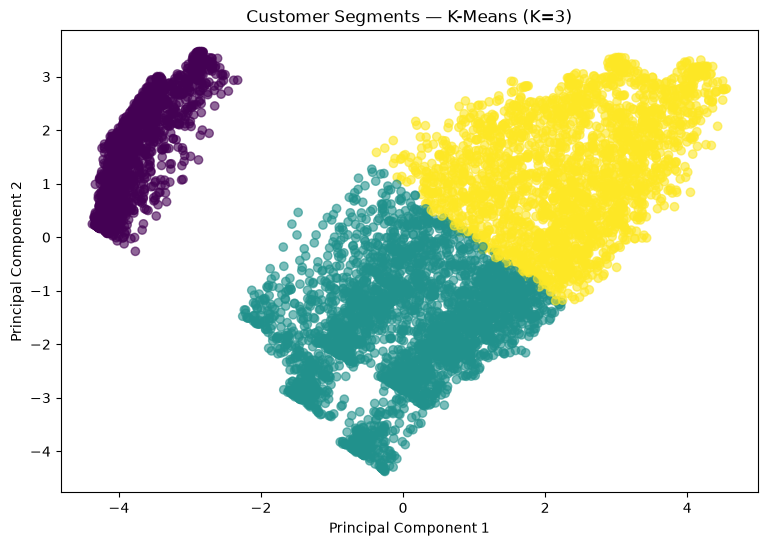

In [22]:
plt.figure(figsize=(9, 6))

plt.scatter(
    X_pca_2d[:, 0],
    X_pca_2d[:, 1],
    c=cluster_labels,
    alpha=0.6
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Customer Segments — K-Means (K=3)")

plt.show()